# EXPLORATORY DATA ANALYSIS FOR TITANIC DATASET

step 1: importing libraries

In [1]:
# Import NumPy for numerical operations
import numpy as np

# Import Pandas for data manipulation and analysis
import pandas as pd

# Import Matplotlib for creating static, interactive, and animated visualizations
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization
import seaborn as sns

# Set default style for plots for better aesthetics
sns.set_style('whitegrid')

# Optionally, set display options for Pandas DataFrames to show more columns/rows
pd.set_option('display.max_columns', None) # Display all columns
pd.set_option('display.max_rows', None)    # Display all rows

Step 2: loading the data set

In [2]:
from google.colab import files
import io

print("Please upload your CSV file:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
    # Read the uploaded CSV file into a pandas DataFrame
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first 5 rows of the DataFrame to verify the load
display(df.head())

Please upload your CSV file:


Saving Titanic dataset.csv to Titanic dataset.csv
User uploaded file "Titanic dataset.csv" with length 29474 bytes


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Understanding Dataset

In [3]:
df.tail() #To display the last five rows and columns in the dataset


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [4]:
df.shape #to show the number of rows and columns in the dataset

(418, 12)

In [5]:
df.columns #to show the column names in the dataset

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df. info() #to show columns and the number of non blank entries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [7]:
df.isnull() .sum() #to show the total number of blank cells in the dataset

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [8]:
df.describe() #to display statistical

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Step 4 Data Cleaning

In [9]:
df.duplicated() .sum() #to check duplicate rows

np.int64(0)

In [10]:
df['Sex'] = df['Sex'].astype('category') #converting sex column to categorical
df['Embarked'] = df['Embarked'].astype('category') #converting embarked column to categorical
df['Pclass'] = df['Pclass'].astype('category') #converting pclass column to categorical
df['Cabin'] = df['Cabin'].astype('category') #converting cabin to categorical

In [11]:
median_age = df['Age'].median()
# Fill missing 'Age' values with the median age
df['Age'] = df['Age'].fillna(median_age)

# Convert 'Age' column to integer type
df['Age'] = df['Age'].astype(int)

In [12]:
# Display the updated data types to confirm the change
display(df.dtypes)

,0
PassengerId,int64
Survived,int64
Pclass,category
Name,object
Sex,category
Age,int64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [13]:
#to check for inconsistency in the different columns
display(df['Sex'].value_counts())


,count
Sex,
male,266
female,152


In [14]:
(df['Embarked'].value_counts())



,count
Embarked,
S,270
C,102
Q,46


In [15]:
(df['Cabin'].value_counts())

,count
Cabin,
B57 B59 B63 B66,3
A34,2
C78,2
E34,2
C23 C25 C27,2
C31,2
C6,2
C55 C57,2
C101,2


Text(0, 0.5, 'Age')

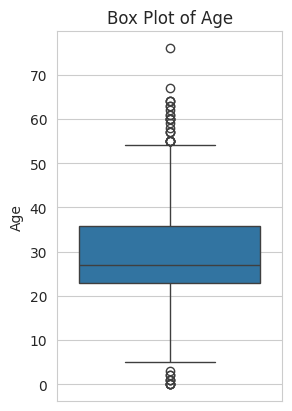

In [16]:
#a boxplot to visualise age and identify outliers
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')

Insights: this box plot shows that the majority of passengersbare concentrated between approximately 20 and 40 years old, suggesting a relatively young adult population.

Text(0, 0.5, 'Fare')

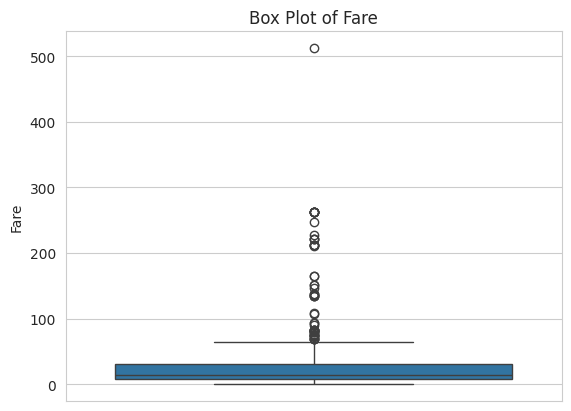

In [17]:
sns.boxplot(y=df['Fare'])
plt.title('Box Plot of Fare')
plt.ylabel('Fare')

Insights: The majority of passengers went for the cheap and afforadable fare,  This suggests that most tickets were inexpensive, hence the large number of passengers in the 2nd class

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  418 non-null    int64   
 1   Survived     418 non-null    int64   
 2   Pclass       418 non-null    category
 3   Name         418 non-null    object  
 4   Sex          418 non-null    category
 5   Age          418 non-null    int64   
 6   SibSp        418 non-null    int64   
 7   Parch        418 non-null    int64   
 8   Ticket       418 non-null    object  
 9   Fare         417 non-null    float64 
 10  Cabin        91 non-null     category
 11  Embarked     418 non-null    category
dtypes: category(4), float64(1), int64(5), object(2)
memory usage: 30.9+ KB


### Handling Missing Values in 'Age' and Converting to Integer

Step 5 univeriate Analysis

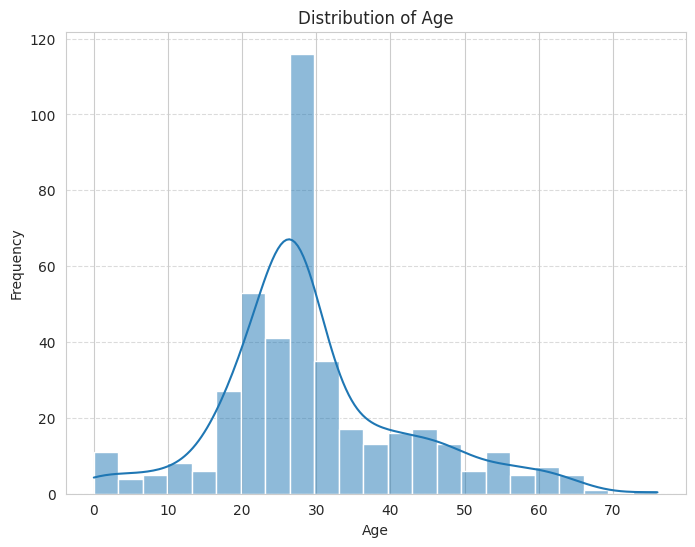

In [19]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Age', kde=True, data=df) # Changed 'age' to 'Age'
plt.title('Distribution of Age') # Changed 'age' to 'Age'
plt.xlabel('Age') # Changed 'age' to 'Age'
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Insight 1: The most occuring age range in the titanic ship is around 30 years old.

2. The numbercof passengers decreases as age increases showing that the titanic had a relatively young passenger population.


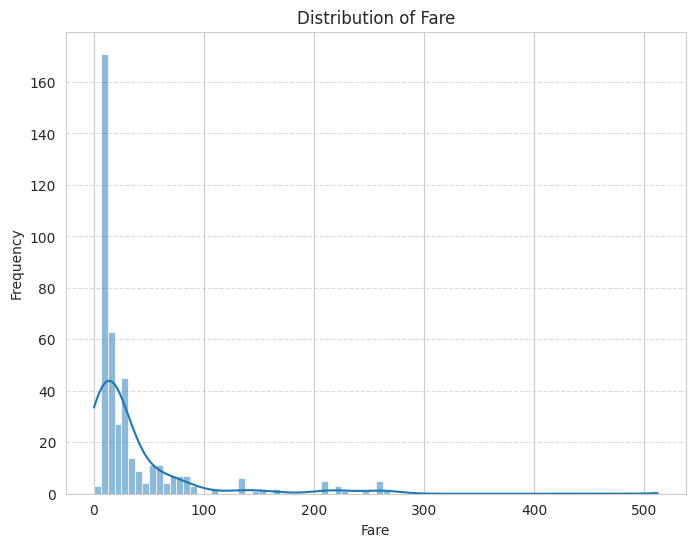

In [20]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Fare', kde=True, data=df) # Changed 'fare' to 'Fare'
plt.title('Distribution of Fare') # Changed 'fare' to 'Fare'
plt.xlabel('Fare') # Changed 'fare' to 'Fare'
plt.ylabel('Frequency') # Changed to a string literal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight 2: This shows that most passengers paid low fare, while only a few cound afford the high fare

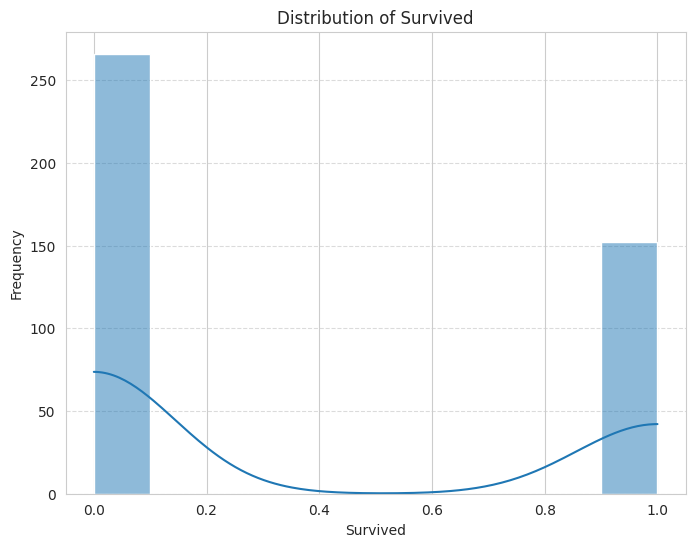

In [21]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Survived', kde=True, data=df) # Changed 'survived' to 'Survived'
plt.title('Distribution of Survived') # Changed 'survived' to 'Survived'
plt.xlabel('Survived') # Changed 'survived' to 'Survived'
plt.ylabel('Frequency') # Changed to a string literal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight : we have more deaths than survival. Approximately 60% died while 40% percent survived

Step 6: Bivariate Analysis

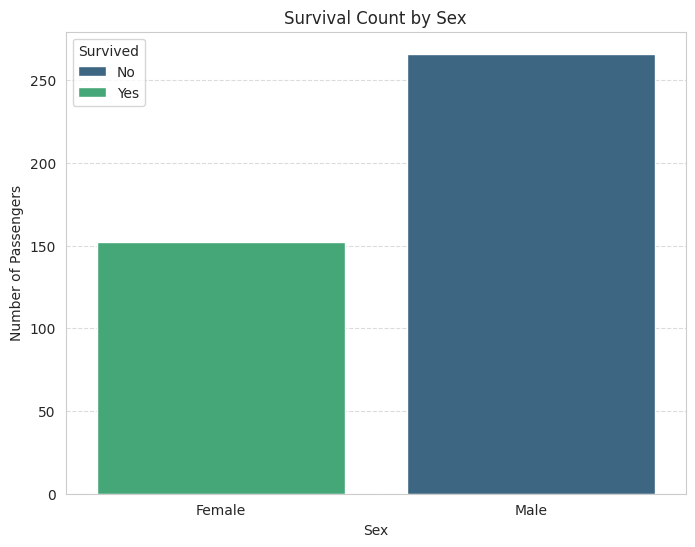

In [22]:
#Create a count plot to visualize the relationship between 'Sex' and 'Survived'
# 'x' is 'Sex', 'hue' is 'Survived' to group bars by survival status, and 'data' is our DataFrame 'df'.
#palette='viridis' sets the color scheme.
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Sex') # Set the chart title
plt.xlabel('Sex') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.xticks(ticks=[0, 1], labels=['Female', 'Male']) # Custom x-axis labels for clarity
plt.legend(title='Survived', labels=['No', 'Yes']) # Add a legend for survival status
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot


Insight 4: this visuals show that a higher proportion of female survived more than the male. this suggest that gender strongly influenced survival outcomes on the titanic.

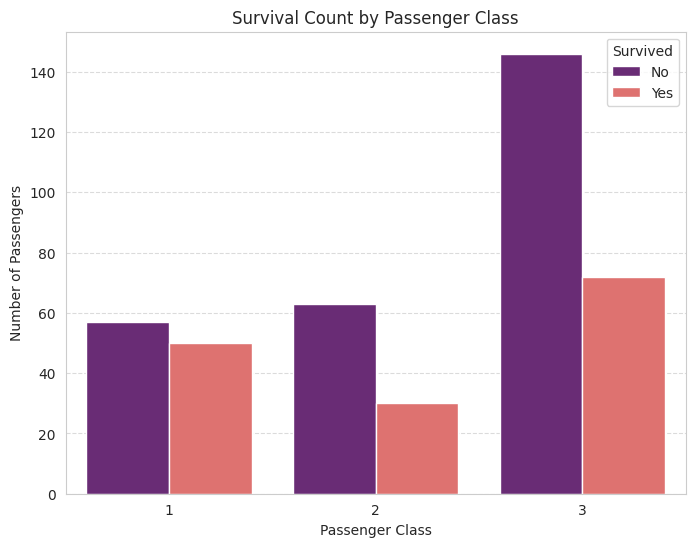

In [23]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='magma')
plt.title('Survival Count by Passenger Class') # Set the chart title
plt.xlabel('Passenger Class') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.legend(title='Survived', labels=['No', 'Yes']) # Add a legend for survival status
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot


Insight: passengers in the first class had the highest survival count, while passengers third class had a record of more death

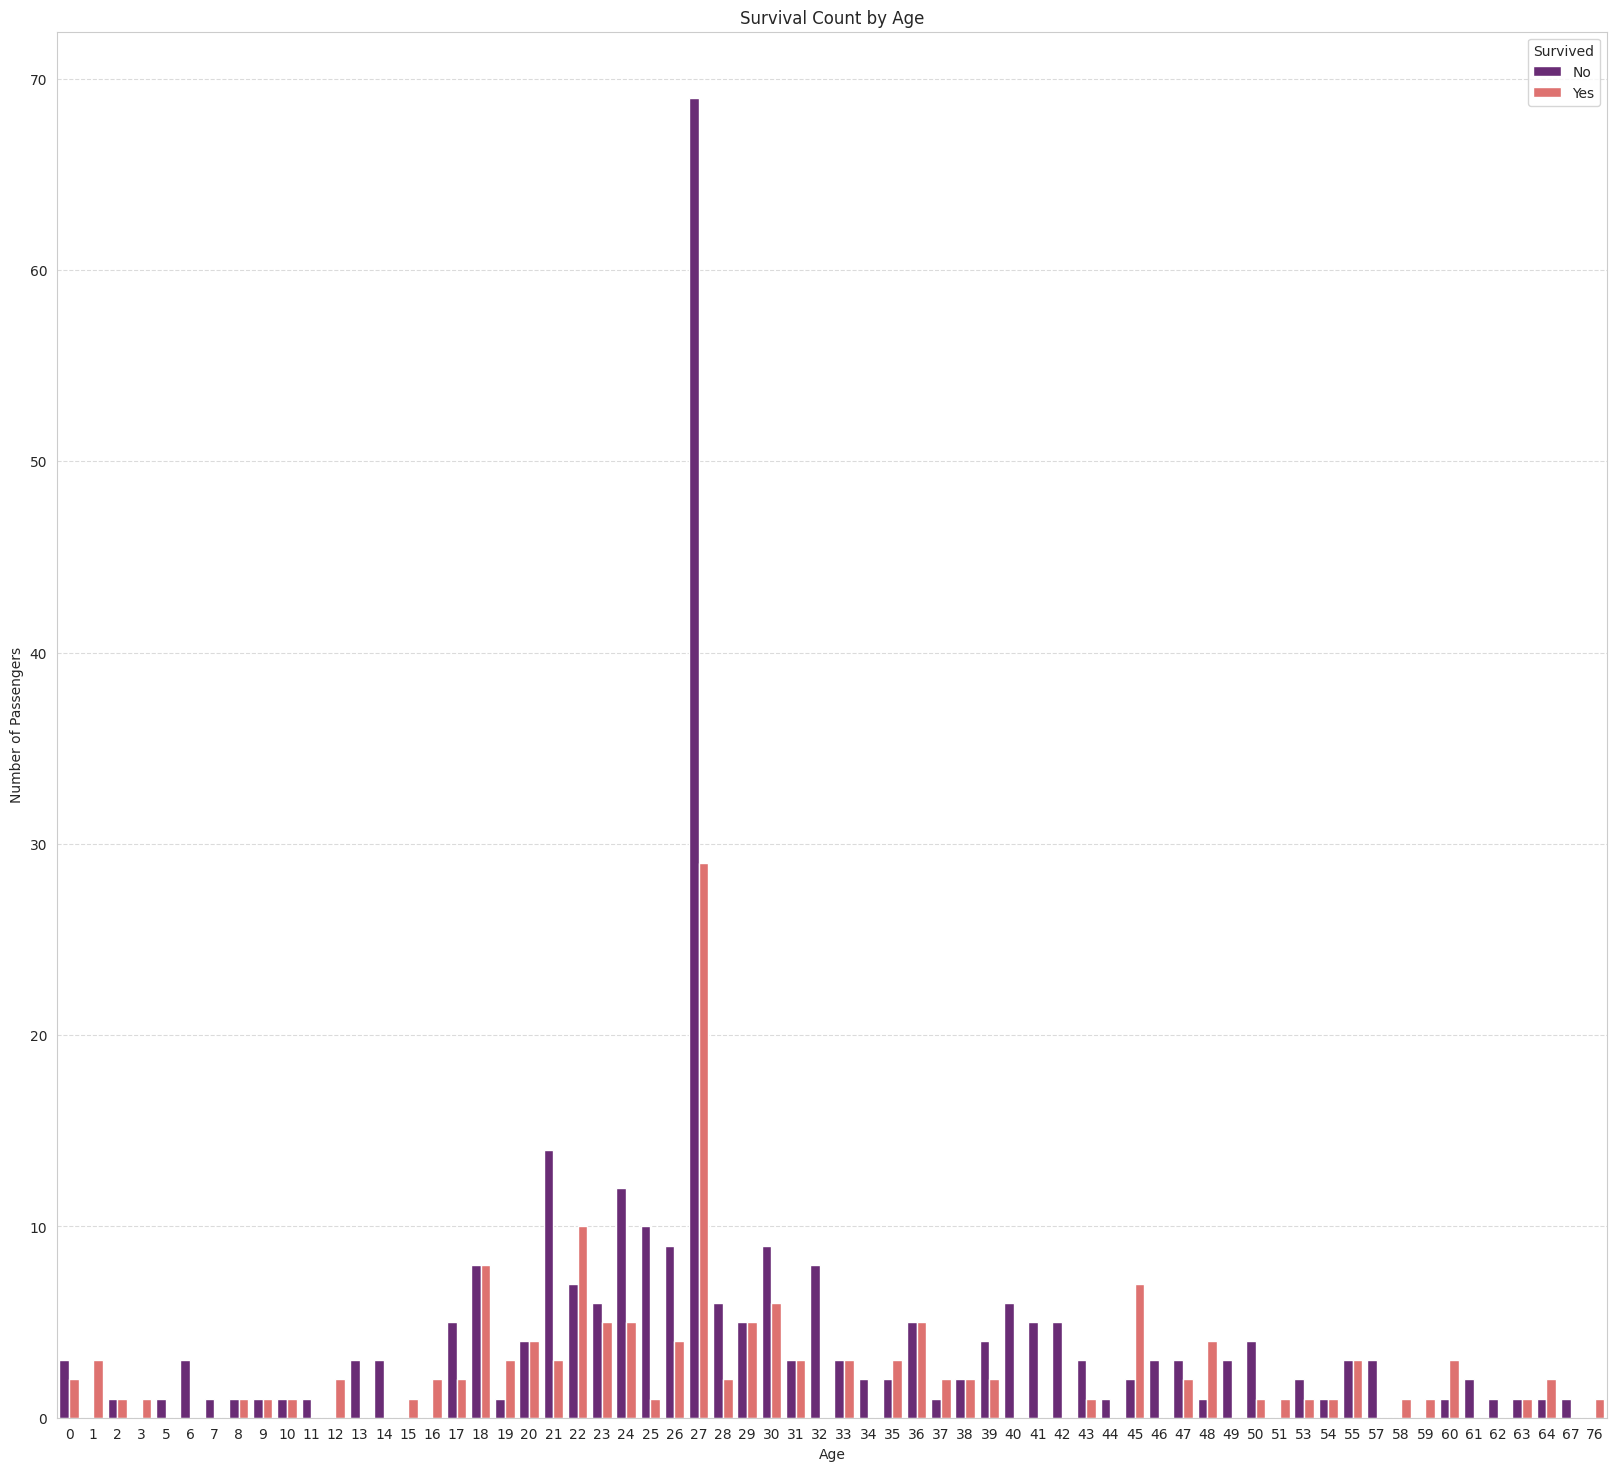

In [24]:
plt.figure(figsize=(20, 18))
sns.countplot(x='Age', hue='Survived', data=df, palette='magma')
plt.title('Survival Count by Age') # Set the chart title
plt.xlabel('Age') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.legend(title='Survived', labels=['No', 'Yes']) # Add a legend for survival status
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot


The largest number of passengers falls within the young adult age range, 20s and 30s, and for many ages within this group, the count of non-survivors significantly outweighs the count of survivors.

Passengers in older age groups e.g., 60s and above generally exhibit very low survival counts.

Step 7: Multivariate Analysis

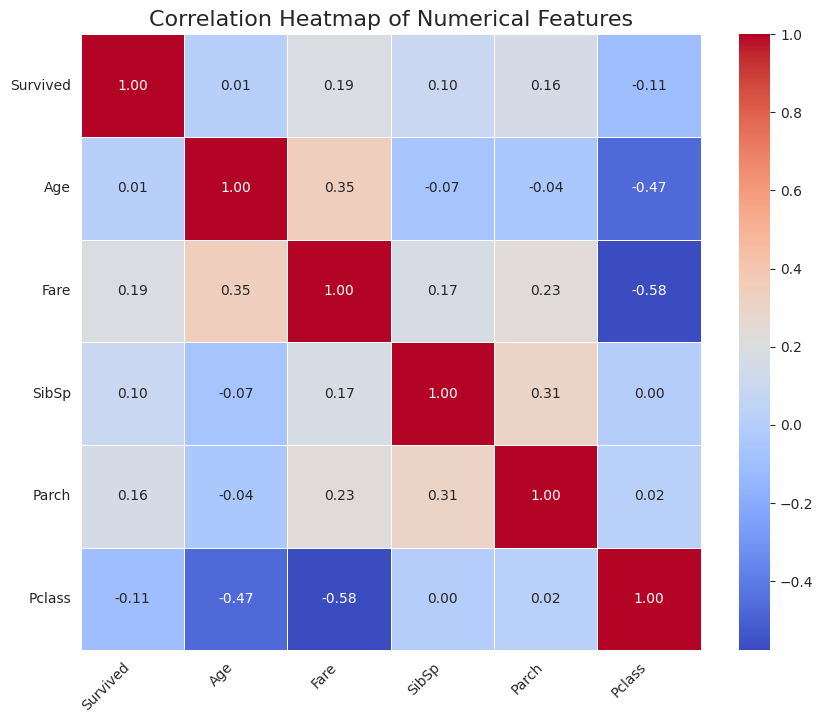

In [25]:
numerical_features = ['Survived', 'Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
# Calculate the pairwise correlation between selected numerical features.
# The .corr() method computes the standard correlation coefficient.
correlation_matrix = df[numerical_features].corr()

# Create a heatmap to visualize the correlation matrix.
plt.figure(figsize=(10, 8)) # Set the size of the plot for optimal readability.
sns.heatmap(correlation_matrix,
            annot=True,     # Display the correlation coefficients on the heatmap cells.
            cmap='coolwarm',  # Use a diverging colormap ('coolwarm' shows positive/negative correlations).
            fmt='.2f',      # Format the annotations to two decimal places.
            linewidths=.5)  # Add lines between cells for better visual separation.
plt.title('Correlation Heatmap of Numerical Features', fontsize=16) # Set a descriptive chart title.
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better legibility.
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal.
plt.show() # Display the generated plot.

**Fare and Survival**: There is a positive correlation between Fare and Survived, suggesting that passengers who paid higher fares had a moderately better chance of survival.

**Passenger Class and Survival**: A weak negative correlation exists between Survived and Pclass  This indicates that belonging to a lower numerical passenger class, 1st class is slightly associated with a higher survival rate.

**Age's Limited Influence on Survival**: Age shows a very weak positive correlation with Survived, implying that age itself does not have a strong linear relationship with survival in this dataset.

**Strong Inverse Relationship between Fare and Pclass:** Fare and Pclass exhibit a strong negative correlation. This is expected, as passengers in higher classes, lower Pclass number typically paid more expensive fares.

**Age and Passenger Class Association:** There is a moderate negative correlation between Age and Pclass, which suggests that older passengers were more likely to be in higher passenger classes e.g., 1st or 2nd class than younger passengers.


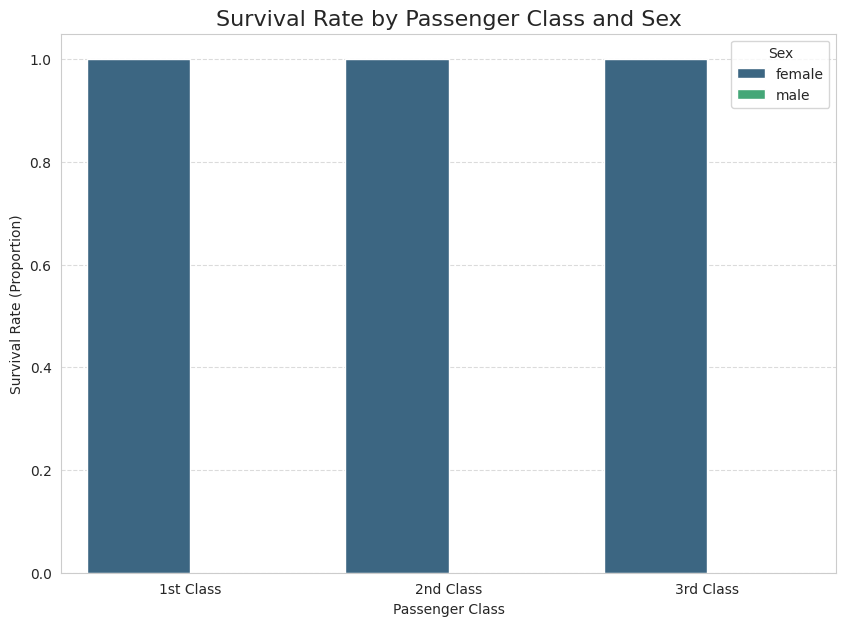

In [26]:
# Calculate the mean survival rate grouped by 'Pclass' and 'Sex'.
# This aggregates the data to show the proportion of survivors (mean of 'Survived')
# for each unique combination of passenger class and gender.
# setting observed=False ensures that all categories, even those not present in a subgroup, are shown.
mean_survival_pclass_sex = df.groupby(['Pclass', 'Sex'], observed=False)['Survived'].mean().reset_index()

# Create a grouped bar plot to visualize the survival rate.
# 'x' represents Pclass on the horizontal axis.
# 'y' represents the calculated mean 'Survived' (survival rate) on the vertical axis.
# 'hue' is set to 'Sex' to create separate bars for 'male' and 'female' within each Pclass group.
plt.figure(figsize=(10, 7)) # Set the size of the plot for better readability.
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=mean_survival_pclass_sex, palette='viridis')
plt.title('Survival Rate by Passenger Class and Sex', fontsize=16) # Set a descriptive chart title.
plt.xlabel('Passenger Class') # Set the x-axis label.
plt.ylabel('Survival Rate (Proportion)') # Set the y-axis label.
# Customize x-axis tick labels for clarity.
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.legend(title='Sex') # Add a legend to distinguish between male and female bars.
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid for easier comparison of rates.
plt.show() # Display the generated plot.

Insights: Feamales had the highest survival rates across all passenger classes.

In this particular dataset, gender appears to be the sole determinant of survival, completely overriding the influence of passenger class.